TESTING WITH RANDOM FOREST CLASSIFIER

In [14]:
import pandas as pd
import numpy as np
import os

In [15]:
pathA = r'data\processed\aggregated_setA.csv'
pathB = r'data\processed\aggregated_setB.csv'

dfA = pd.read_csv(pathA)
dfB = pd.read_csv(pathB)

In [16]:
pd.set_option('display.max_rows', None)
dfA.isna().sum()

HR_mean                  1
HR_std                   6
HR_max                   1
HR_min                   1
HR_count                 0
O2Sat_mean              12
O2Sat_std               22
O2Sat_max               12
O2Sat_min               12
O2Sat_count              0
Temp_mean              235
Temp_std               475
Temp_max               235
Temp_min               235
Temp_count               0
SBP_mean               258
SBP_std                318
SBP_max                258
SBP_min                258
SBP_count                0
MAP_mean                 2
MAP_std                 10
MAP_max                  2
MAP_min                  2
MAP_count                0
DBP_mean              7384
DBP_std               7563
DBP_max               7384
DBP_min               7384
DBP_count                0
Resp_mean               28
Resp_std                51
Resp_max                28
Resp_min                28
Resp_count               0
BaseExcess_mean       7684
BaseExcess_std        9412
B

In [17]:
to_drop = ['Fibrinogen_mean','Fibrinogen_std','Fibrinogen_max','Fibrinogen_min','Fibrinogen_count','Unit1_first','Unit2_first']
impute_cols = [
    "HR_mean",
    "HR_std",
    "HR_max",
    "HR_min",
    "O2Sat_mean",
    "O2Sat_std",
    "O2Sat_max",
    "O2Sat_min",
    "Temp_mean",
    "Temp_std",
    "Temp_max",
    "Temp_min",
    "SBP_mean",
    "SBP_std",
    "SBP_max",
    "SBP_min",
    "MAP_mean",
    "MAP_std",
    "MAP_max",
    "MAP_min",
    "DBP_mean",
    "DBP_std",
    "DBP_max",
    "DBP_min",
    "Resp_mean",
    "Resp_std",
    "Resp_max",
    "Resp_min",
    "BaseExcess_mean",
    "BaseExcess_std",
    "BaseExcess_max",
    "BaseExcess_min",
    "HCO3_mean",
    "HCO3_std",
    "HCO3_max",
    "HCO3_min",
    "Lactate_mean",
    "Lactate_std",
    "Lactate_max",
    "Lactate_min",
    "Glucose_mean",
    "Glucose_std",
    "Glucose_max",
    "Glucose_min",
    "BUN_mean",
    "BUN_std",
    "BUN_max",
    "BUN_min",
    "Creatinine_mean",
    "Creatinine_std",
    "Creatinine_max",
    "Creatinine_min",
    "Calcium_mean",
    "Calcium_std",
    "Calcium_max",
    "Calcium_min",
    "Chloride_mean",
    "Chloride_std",
    "Chloride_max",
    "Chloride_min",
    "Magnesium_mean",
    "Magnesium_std",
    "Magnesium_max",
    "Magnesium_min",
    "Phosphate_mean",
    "Phosphate_std",
    "Phosphate_max",
    "Phosphate_min",
    "Potassium_mean",
    "Potassium_std",
    "Potassium_max",
    "Potassium_min",
    "Hct_mean",
    "Hct_std",
    "Hct_max",
    "Hct_min",
    "Hgb_mean",
    "Hgb_std",
    "Hgb_max",
    "Hgb_min",
    "WBC_mean",
    "WBC_std",
    "WBC_max",
    "WBC_min",
    "Platelets_mean",
    "Platelets_std",
    "Platelets_max",
    "Platelets_min",
    "PTT_mean",
    "PTT_std",
    "PTT_max",
    "PTT_min",
    "FiO2_mean",
    "FiO2_std",
    "FiO2_max",
    "FiO2_min",
    "pH_mean",
    "pH_std",
    "pH_max",
    "pH_min",
    "PaCO2_mean",
    "PaCO2_std",
    "PaCO2_max",
    "PaCO2_min",
    "HospAdmTime_first"
]

In [18]:
for col in dfA.columns:
    if col in to_drop:
        dfA.drop(columns = [col], inplace = True) 
        dfB.drop(columns = [col], inplace = True) 
    if col in impute_cols:
        dfA[col] = dfA[col].median()
        dfB[col] = dfB[col].median()

In [19]:
dfA.isna().sum()

HR_mean              0
HR_std               0
HR_max               0
HR_min               0
HR_count             0
O2Sat_mean           0
O2Sat_std            0
O2Sat_max            0
O2Sat_min            0
O2Sat_count          0
Temp_mean            0
Temp_std             0
Temp_max             0
Temp_min             0
Temp_count           0
SBP_mean             0
SBP_std              0
SBP_max              0
SBP_min              0
SBP_count            0
MAP_mean             0
MAP_std              0
MAP_max              0
MAP_min              0
MAP_count            0
DBP_mean             0
DBP_std              0
DBP_max              0
DBP_min              0
DBP_count            0
Resp_mean            0
Resp_std             0
Resp_max             0
Resp_min             0
Resp_count           0
BaseExcess_mean      0
BaseExcess_std       0
BaseExcess_max       0
BaseExcess_min       0
BaseExcess_count     0
HCO3_mean            0
HCO3_std             0
HCO3_max             0
HCO3_min   

Since, Random Forest Classifier manages outliers automatically let me test without log transformation

In [20]:
target = ["SepsisLabel_max"]
features = [
    "HR_mean",
    "HR_std",
    "HR_max",
    "HR_min",
    "HR_count",
    "O2Sat_mean",
    "O2Sat_std",
    "O2Sat_max",
    "O2Sat_min",
    "O2Sat_count",
    "Temp_mean",
    "Temp_std",
    "Temp_max",
    "Temp_min",
    "Temp_count",
    "SBP_mean",
    "SBP_std",
    "SBP_max",
    "SBP_min",
    "SBP_count",
    "MAP_mean",
    "MAP_std",
    "MAP_max",
    "MAP_min",
    "MAP_count",
    "DBP_mean",
    "DBP_std",
    "DBP_max",
    "DBP_min",
    "DBP_count",
    "Resp_mean",
    "Resp_std",
    "Resp_max",
    "Resp_min",
    "Resp_count",
    "BaseExcess_mean",
    "BaseExcess_std",
    "BaseExcess_max",
    "BaseExcess_min",
    "BaseExcess_count",
    "HCO3_mean",
    "HCO3_std",
    "HCO3_max",
    "HCO3_min",
    "HCO3_count",
    "Lactate_mean",
    "Lactate_std",
    "Lactate_max",
    "Lactate_min",
    "Lactate_count",
    "Glucose_mean",
    "Glucose_std",
    "Glucose_max",
    "Glucose_min",
    "Glucose_count",
    "BUN_mean",
    "BUN_std",
    "BUN_max",
    "BUN_min",
    "BUN_count",
    "Creatinine_mean",
    "Creatinine_std",
    "Creatinine_max",
    "Creatinine_min",
    "Creatinine_count",
    "Calcium_mean",
    "Calcium_std",
    "Calcium_max",
    "Calcium_min",
    "Calcium_count",
    "Chloride_mean",
    "Chloride_std",
    "Chloride_max",
    "Chloride_min",
    "Chloride_count",
    "Magnesium_mean",
    "Magnesium_std",
    "Magnesium_max",
    "Magnesium_min",
    "Magnesium_count",
    "Phosphate_mean",
    "Phosphate_std",
    "Phosphate_max",
    "Phosphate_min",
    "Phosphate_count",
    "Potassium_mean",
    "Potassium_std",
    "Potassium_max",
    "Potassium_min",
    "Potassium_count",
    "Hct_mean",
    "Hct_std",
    "Hct_max",
    "Hct_min",
    "Hct_count",
    "Hgb_mean",
    "Hgb_std",
    "Hgb_max",
    "Hgb_min",
    "Hgb_count",
    "WBC_mean",
    "WBC_std",
    "WBC_max",
    "WBC_min",
    "WBC_count",
    "Platelets_mean",
    "Platelets_std",
    "Platelets_max",
    "Platelets_min",
    "Platelets_count",
    "PTT_mean",
    "PTT_std",
    "PTT_max",
    "PTT_min",
    "PTT_count",
    "FiO2_mean",
    "FiO2_std",
    "FiO2_max",
    "FiO2_min",
    "FiO2_count",
    "pH_mean",
    "pH_std",
    "pH_max",
    "pH_min",
    "pH_count",
    "PaCO2_mean",
    "PaCO2_std",
    "PaCO2_max",
    "PaCO2_min",
    "PaCO2_count",
    "Age_first",
    "Gender_first",
    "HospAdmTime_first",
    "ICULOS_max"
]

In [21]:
X = dfA[features]
y = dfA[target]
X_test = dfB[features]
y_test = dfB[target]

In [22]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators = 100,
                               criterion = 'gini',
                               max_depth = None,
                               min_samples_split = 2,
                               min_samples_leaf = 1,
                               max_features = "sqrt",
                               class_weight = "balanced",
                               n_jobs = 1,
                               random_state = 42)

In [23]:
model.fit(X,y)

c:\users\lenovo\.pyenv\pyenv-win\versions\3.7.4\lib\site-packages\ipykernel_launcher.py:1: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  """Entry point for launching an IPython kernel.


RandomForestClassifier(class_weight='balanced', max_features='sqrt', n_jobs=1,
                       random_state=42)

In [24]:
y_predicted = model.predict(X_test)

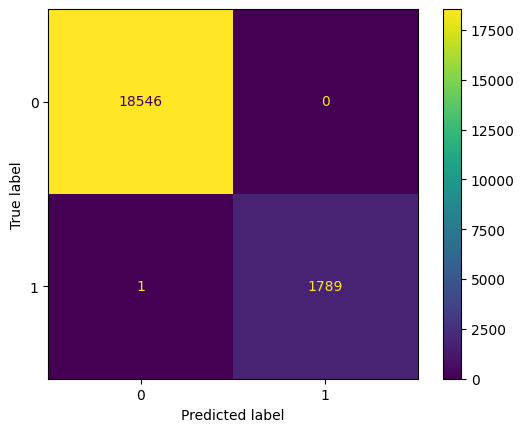

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

cm = confusion_matrix(y_test, y_predicted)
ConfusionMatrixDisplay(confusion_matrix = cm).plot()

In [28]:
print(classification_report(y_test, y_predicted))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18546
           1       1.00      1.00      1.00      1790

    accuracy                           1.00     20336
   macro avg       1.00      1.00      1.00     20336
weighted avg       1.00      1.00      1.00     20336



We got abnormally accurate prediction. This means something is wrong. Let use check

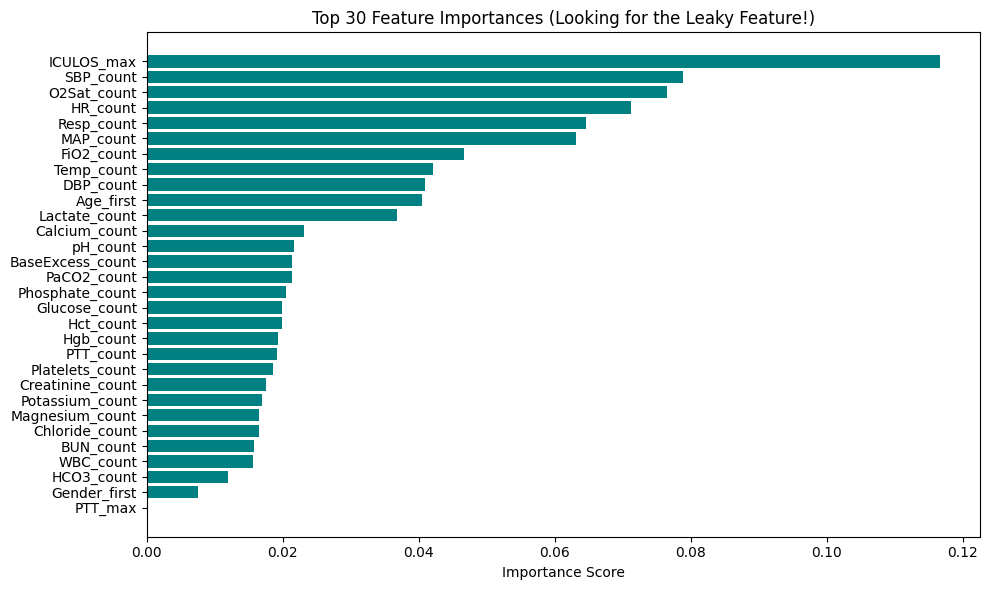

In [36]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(30)

plt.figure(figsize=(10, 6))
plt.barh(feature_imp_df['Feature'][::-1], feature_imp_df['Importance'][::-1], color='teal')
plt.xlabel('Importance Score')
plt.title('Top 30 Feature Importances (Looking for the Leaky Feature!)')
plt.tight_layout()
plt.show()

we need to remove this leaky features since most of them are not important (count ones)

In [47]:
leaky_features_to_drop = [
    'ICULOS_max',
    'HR_count',
    'O2Sat_count',
    'Temp_count',
    'SBP_count',
    'MAP_count',
    'DBP_count',
    'Resp_count',
    'FiO2_count',
    'Lactate_count',
    'Calcium_count',
    'pH_count',
    'BaseExcess_count',
    'PaCO2_count',
    'Phosphate_count',
    'Glucose_count',
    'Hct_count',
    'Hgb_count',
    'PTT_count',
    'Platelets_count',
    'Creatinine_count',
    'Potassium_count',
    'Magnesium_count',
    'Chloride_count',
    'BUN_count',
    'WBC_count',
    'HCO3_count',
    'Bilirubin_total_count',
    'TroponinI_count'
]

features_final = [f for f in dfA.columns if f not in leaky_features_to_drop]

dfA_final = dfA[features_final]
dfB_final = dfB[features_final]

In [48]:
dfA_final.info(verbose = True, show_counts = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20336 entries, 0 to 20335
Data columns (total 108 columns):
 #    Column             Non-Null Count  Dtype  
---   ------             --------------  -----  
 0    HR_mean            20336 non-null  float64
 1    HR_std             20336 non-null  float64
 2    HR_max             20336 non-null  float64
 3    HR_min             20336 non-null  float64
 4    O2Sat_mean         20336 non-null  float64
 5    O2Sat_std          20336 non-null  float64
 6    O2Sat_max          20336 non-null  float64
 7    O2Sat_min          20336 non-null  float64
 8    Temp_mean          20336 non-null  float64
 9    Temp_std           20336 non-null  float64
 10   Temp_max           20336 non-null  float64
 11   Temp_min           20336 non-null  float64
 12   SBP_mean           20336 non-null  float64
 13   SBP_std            20336 non-null  float64
 14   SBP_max            20336 non-null  float64
 15   SBP_min            20336 non-null  float64
 16   MA

In [49]:
X_train = dfA_final.drop(columns = ['SepsisLabel_max'])
y_train = dfA_final[target]

X_test_final = dfB_final.drop(columns = ['SepsisLabel_max']) 
y_test_final = dfB_final[target]

In [50]:
rf_clf = RandomForestClassifier(n_estimators = 100,
                               criterion = 'gini',
                               max_depth = None,
                               min_samples_split = 2,
                               min_samples_leaf = 1,
                               max_features = "sqrt",
                               class_weight = "balanced",
                               n_jobs = 1,
                               random_state = 42)

In [51]:
rf_clf.fit(X_train, y_train)

c:\users\lenovo\.pyenv\pyenv-win\versions\3.7.4\lib\site-packages\ipykernel_launcher.py:1: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  """Entry point for launching an IPython kernel.


RandomForestClassifier(class_weight='balanced', max_features='sqrt', n_jobs=1,
                       random_state=42)

In [52]:
y_predicted_final = rf_clf.predict(X_test_final)

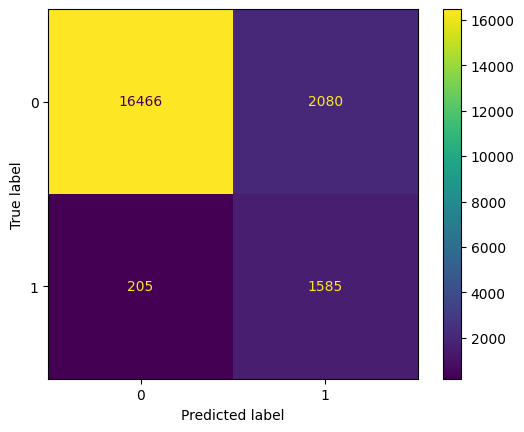

In [53]:
cm_final = confusion_matrix(y_test_final, y_predicted_final)

ConfusionMatrixDisplay(confusion_matrix = cm_final).plot()

In [54]:
print(classification_report(y_test_final, y_predicted_final))

              precision    recall  f1-score   support

           0       0.99      0.89      0.94     18546
           1       0.43      0.89      0.58      1790

    accuracy                           0.89     20336
   macro avg       0.71      0.89      0.76     20336
weighted avg       0.94      0.89      0.90     20336

